# Train Schedule coordination – train model

`data/appointment_waittime.csv` → `models/schedule_waittime.joblib`

In [9]:
from pathlib import Path
import json, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, joblib, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
ROOT = Path.cwd() if (Path.cwd()/'data').exists() else Path.cwd().parent
DATA = ROOT/'data'/'appointment_waittime.csv'
MODEL_DIR = ROOT/'models'
MODEL_DIR.mkdir(exist_ok=True)
print(ROOT, DATA.exists())

d:\TTTN-VaxCare-2026\vaxcare-ai True


## 1. Load & khám phá

In [10]:
df = pd.read_csv(DATA)
print(df.shape)
df.head()

(3600, 16)


,date,facility_id,facility_name,day_of_week,is_weekend,is_holiday,hour,time_slot,capacity,capacity_per_slot_base,booked,occupancy_rate,overload_probability,wait_time_minutes,is_busy,alert_threshold
0,2026-06-12,1,VaxCare Phú Nhuận,4,0,0,13,13:00:00,17,15,4,0.235,0.2016,12,0,50
1,2026-06-06,1,VaxCare Phú Nhuận,5,1,0,10,10:00:00,20,15,7,0.350,0.2212,17,0,50
2,2026-05-07,1,VaxCare Phú Nhuận,3,0,0,15,15:00:00,16,15,9,0.562,0.3495,19,0,50
3,2026-05-25,1,VaxCare Phú Nhuận,0,0,0,15,15:00:00,19,15,11,0.579,0.5083,17,0,50
4,2026-06-26,1,VaxCare Phú Nhuận,4,0,0,14,14:00:00,19,15,19,1.000,0.9243,68,1,50


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
facility_id,3600.0,6.500000,3.452532,1.00,3.7500,6.5000,9.250000,12.00
day_of_week,3600.0,3.013333,2.046375,0.00,1.0000,3.0000,5.000000,6.00
is_weekend,3600.0,0.300000,0.458321,0.00,0.0000,0.0000,1.000000,1.00
is_holiday,3600.0,0.013333,0.114714,0.00,0.0000,0.0000,0.000000,1.00
hour,3600.0,12.143333,2.705209,8.00,10.0000,13.0000,15.000000,16.00
capacity,3600.0,13.250000,4.197242,7.00,11.0000,12.0000,16.000000,24.00
capacity_per_slot_base,3600.0,13.000000,2.309722,10.00,11.7500,12.0000,15.000000,18.00
booked,3600.0,6.353056,4.249455,0.00,3.0000,6.0000,9.000000,24.00
occupancy_rate,3600.0,0.476342,0.264928,0.00,0.2730,0.4550,0.667000,1.00
overload_probability,3600.0,0.407670,0.233341,0.01,0.2271,0.3966,0.574325,0.99


## 2. Features

In [12]:
FEATURES = ["day_of_week","is_weekend","is_holiday","hour","capacity","booked","occupancy_rate"]
TARGET = "wait_time_minutes"
X, y = df[FEATURES], df[TARGET]
X.describe()

,day_of_week,is_weekend,is_holiday,hour,capacity,booked,occupancy_rate
count,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000
mean,3.013333,0.300000,0.013333,12.143333,13.250000,6.353056,0.476342
std,2.046375,0.458321,0.114714,2.705209,4.197242,4.249455,0.264928
min,0.000000,0.000000,0.000000,8.000000,7.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,10.000000,11.000000,3.000000,0.273000
50%,3.000000,0.000000,0.000000,13.000000,12.000000,6.000000,0.455000
75%,5.000000,1.000000,0.000000,15.000000,16.000000,9.000000,0.667000
max,6.000000,1.000000,1.000000,16.000000,24.000000,24.000000,1.000000


## 3. Train XGBoost

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.08, subsample=0.85, colsample_bytree=0.85, min_child_weight=3, reg_lambda=1.0, objective='reg:squarederror', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print('trained', len(X_train))

trained 2880


## 4. Đánh giá MAE / RMSE / R²

{'mae': 5.8116, 'rmse': 7.7195, 'r2': 0.8069}


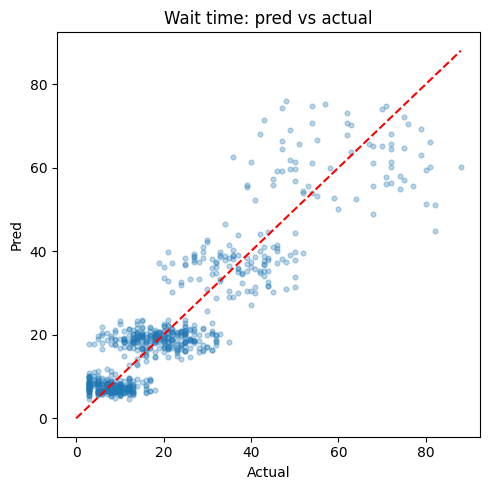

In [14]:
pred = np.clip(model.predict(X_test), 0, None)
metrics = {'mae': round(float(mean_absolute_error(y_test, pred)), 4), 'rmse': round(float(np.sqrt(mean_squared_error(y_test, pred))), 4), 'r2': round(float(r2_score(y_test, pred)), 4)}
print(metrics)
plt.figure(figsize=(5,5)); plt.scatter(y_test, pred, alpha=0.3, s=12)
m = max(y_test.max(), pred.max()); plt.plot([0,m],[0,m],'r--')
plt.xlabel('Actual'); plt.ylabel('Pred'); plt.title('Wait time: pred vs actual'); plt.tight_layout(); plt.show()

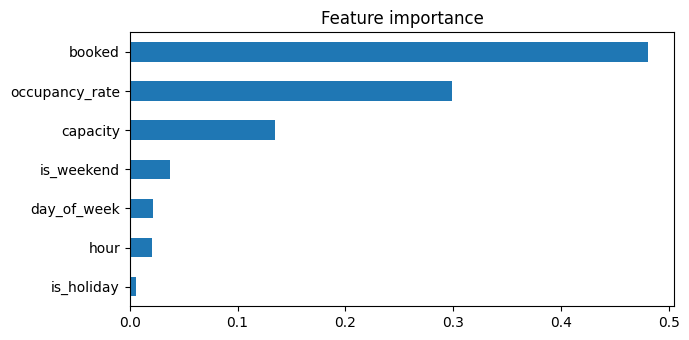

{'day_of_week': 0.0217, 'is_weekend': 0.0374, 'is_holiday': 0.0054, 'hour': 0.0209, 'capacity': 0.1349, 'booked': 0.4809, 'occupancy_rate': 0.2987}


In [15]:
imp = dict(zip(FEATURES, [round(float(x),4) for x in model.feature_importances_]))
pd.Series(imp).sort_values().plot(kind='barh', figsize=(7,3.5), title='Feature importance')
plt.tight_layout(); plt.show(); print(imp)

## 5. Lưu model

In [16]:
artifact = {'model': model, 'features': FEATURES, 'target': TARGET, 'model_version': 'schedule-xgboost-v1', 'metrics': metrics}
out = MODEL_DIR/'schedule_waittime.joblib'
joblib.dump(artifact, out)
(MODEL_DIR/'schedule_metrics.json').write_text(json.dumps(metrics, indent=2))
print('Saved', out)

Saved d:\TTTN-VaxCare-2026\vaxcare-ai\models\schedule_waittime.joblib
